In [19]:
import qetpy as qp
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import pytesdaq.io.hdf5 as h5io
import pickle
import random as rand

In [20]:
h5 = h5io.H5Reader()

def read_file(file_name): 
    traces, info = h5.read_many_events(filepath=file_name, output_format=2, 
                                       include_metadata=True,
                                       adctoamp=True)
    detector_settings = h5.get_detector_config(file_name=file_name)
    channels = info[0]['detector_chans']
    sample_rate = info[0]['sample_rate']
    
    return traces, channels, sample_rate, detector_settings

<IPython.core.display.Javascript object>


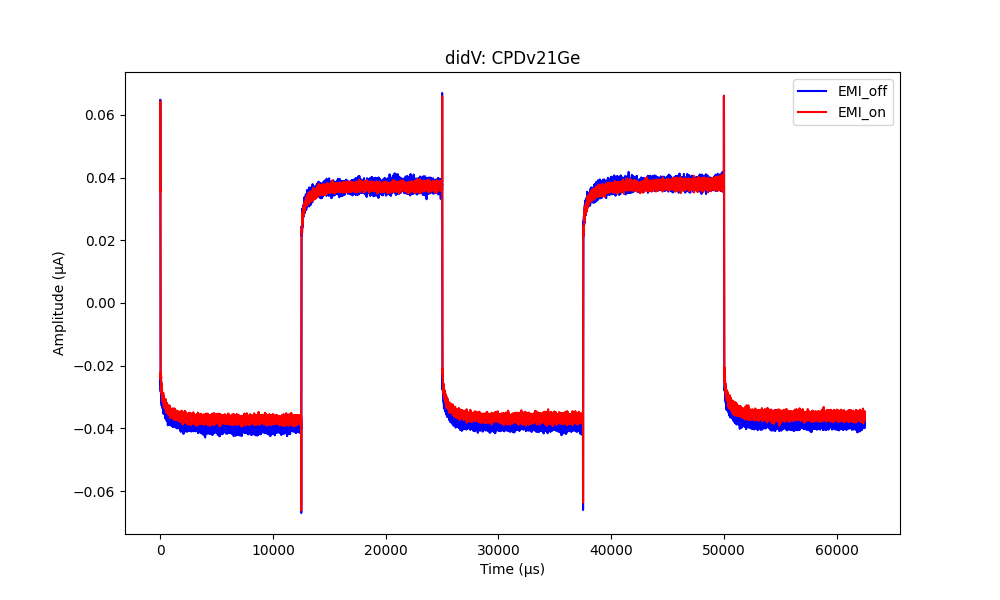

/home/christina/.local/lib/python3.6/site-packages/qetpy/cut/_cut.py:973: UserWarning: The `sgfreq` option has been deprecated and is now ignored when is_didv is True.
  "The `sgfreq` option has been deprecated and "
/home/christina/.local/lib/python3.6/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


CPDv21Ge bias power @ EMI_off = 8.699329903010591 pWatts


/home/christina/.local/lib/python3.6/site-packages/qetpy/cut/_cut.py:973: UserWarning: The `sgfreq` option has been deprecated and is now ignored when is_didv is True.
  "The `sgfreq` option has been deprecated and "


CPDv21Ge bias power @ EMI_on = 8.528817658224947 pWatts


/home/christina/.local/lib/python3.6/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [27]:
#%matplotlib notebook

# channel to calculate power
channel_selection = ['CPDv21Ge']
display_fit = True

# DATA 

data_list = dict()
base_path = '/sdata2/runs/run19/raw'
data_list['EMI_off'] = base_path + '/exttrigger_I2_D20220728_T122012/exttrig_I2_D20220728_T122013_F0001.hdf5'
data_list['EMI_on'] = base_path + '/exttrigger_I2_D20220728_T122406/exttrig_I2_D20220728_T122408_F0001.hdf5'


# intialize Power dictionary
power_dict = dict()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red", "blue"]

# loop data
for emi_status, file in data_list.items():
    
    # load traces all channels [Nbevents, Nb channels, NB samples]
    traces, channels, sample_rate, detector_settings = read_file(file)
    
    # Temporary channels
    channels = ['NoDevice', 'Melange1pcHangingOuter', 'Melange1pcHangingInner', 'CPDv21Ge']
    
    # loop channels
    power_dict[emi_status] = dict()
    for ind, chan in enumerate(channels):
        power_dict[emi_status][chan] = dict()
        
        
        # only selected channels
        if chan not in channel_selection:
            continue
        
        # store 2D trace for the channel
        traces_chan = traces[:,ind,:]
        
        
        # detector settings
        rshunt = float(detector_settings[chan]['shunt_resistance'])
        signal_gen_frequency = float(detector_settings[chan]['signal_gen_frequency'])
        signal_gen_current = float(detector_settings[chan]['signal_gen_current'])
        tes_bias = float(detector_settings[chan]['tes_bias'])
        voltage_bias = tes_bias*rshunt
        rp = 0.003
        
        
        # cut pileup
        cut = qp.autocuts(traces_chan,fs=sample_rate, is_didv=True, 
                          sgfreq=signal_gen_frequency)
        dis_trace = traces_chan[cut].mean(axis=0)
        dis_trace = (dis_trace.max()+dis_trace.min())/2-dis_trace
        
        
        ax.plot(dis_trace*1e6, label=emi_status, color=colors.pop())
        ax.legend()
        ax.set_title("didV: "+chan)
        ax.set_xlabel("Time (μs)")
        ax.set_ylabel("Amplitude (μA)")

        
    
        # Fit data
        didvobj = qp.DIDV(traces_chan[cut], 
                          sample_rate, 
                          signal_gen_frequency, signal_gen_current, 
                          rshunt, rp=rp, dt0=3.4e-6, dutycycle=0.5, add180phase=False)
        didvobj.processtraces()
        didvobj.dofit(2)
        didvobj.dofit(3)
        result = didvobj.fitresult(3)
        
        # display fit
        display_fit = False
        if display_fit:
            didvobj.plot_full_trace()
                    
                
        ###  calc power 
        # TES resistance 
        r_tes = abs(1/result['didv0']) + rp + rshunt
        
        # current in TES 
        i_tes = voltage_bias/(r_tes + rp + rshunt)
        
        # Power = V x I   (- load power rload*i_tes^2  (in pico Watt)
        power_tes = 1e12 *(voltage_bias*i_tes - (rp+rshunt)*pow(i_tes,2))
       
        print(chan + ' bias power @ ' + str(emi_status) + ' = ' + str(power_tes) + ' pWatts')
        
        power_dict[emi_status][chan] = power_tes
        
        
        
                 
           

In [26]:
print(power_dict.keys())
print(power_dict.values())

dict_keys([756, 780, 810, 840, 870, 900])
dict_values([8.796933279237603, 8.752014816864772, 8.702558620877173, 8.614630278880226, 8.531082535388684, 8.470685219701098])


<IPython.core.display.Javascript object>


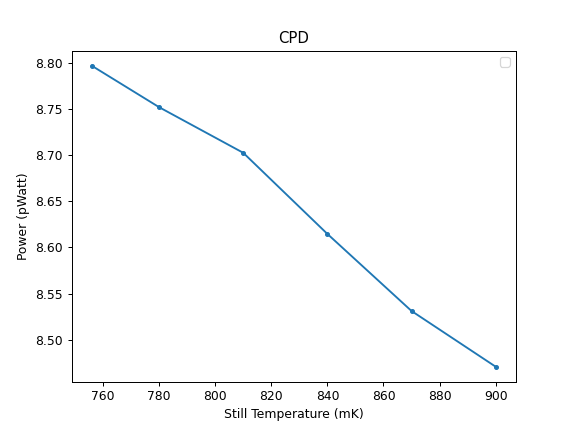

No handles with labels found to put in legend.


In [34]:
# Plot power in function of temperature
plt.plot(power_dict.keys(), power_dict.values(), marker=".")
plt.legend()
plt.ylabel("Power (pWatt)")
plt.xlabel("Still Temperature (mK)")
plt.title("CPD")
plt.show()

In [14]:
print(μs)

SyntaxError: unexpected character after line continuation character (<ipython-input-14-fd2dcd647e5a>, line 1)